# Classical Analysis Harness

This notebook characterizes the D1Q3 and D2Q9 classical baselines before we move to quantum-state emulation. The goal is to quantify accuracy, stability, mass conservation, and runtime across grid sizes and relaxation times.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt

from pq_cfd import (
    default_d1q3_sweep_cases,
    default_d2q9_sweep_cases,
    run_sweep,
    write_sweep_csv,
)
from pq_cfd.analysis import format_grid_shape

In [2]:
output_dir = project_root / ".cache" / "benchmarks"
output_dir.mkdir(parents=True, exist_ok=True)

d1_records = run_sweep(default_d1q3_sweep_cases(amplitude=0.03))
d2_records = run_sweep(default_d2q9_sweep_cases(amplitude=0.03))

write_sweep_csv(d1_records, output_dir / "d1q3_sweep.csv")
write_sweep_csv(d2_records, output_dir / "d2q9_sweep.csv")
write_sweep_csv([*d1_records, *d2_records], output_dir / "classical_sweep.csv")

print(f"D1Q3 cases: {len(d1_records)}")
print(f"D2Q9 cases: {len(d2_records)}")
print(f"CSV output: {output_dir}")

D1Q3 cases: 16
D2Q9 cases: 9
CSV output: c:\Users\NishchayVORA\Documents\PQ_CFD\.cache\benchmarks


D1Q3 isolates the smallest useful LBM structure: a local collision followed by periodic streaming. This is the case we should map first when we build a reversible or statevector-style quantum emulation.

In [3]:
def plot_by_tau(records, y_attr, ylabel, title, *, log_y=True):
    fig, ax = plt.subplots(figsize=(7, 4))
    for tau in sorted({record.tau for record in records}):
        subset = sorted(
            [record for record in records if record.tau == tau],
            key=lambda record: record.grid_points,
        )
        x = [record.grid_points for record in subset]
        y = [max(getattr(record, y_attr), 1e-18) for record in subset]
        ax.plot(x, y, marker="o", label=f"tau={tau}")
    ax.set_xscale("log", base=2)
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel("grid points")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    return fig, ax


def print_best(records, label):
    best = min(records, key=lambda record: record.relative_error)
    print(
        f"{label} best error: {best.relative_error:.3e} "
        f"at grid={format_grid_shape(best.grid_shape)}, tau={best.tau}"
    )

D1Q3 best error: 3.580e-13 at grid=256, tau=1.0


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'D1Q3 runtime'}, xlabel='grid points', ylabel='runtime (s)'>)

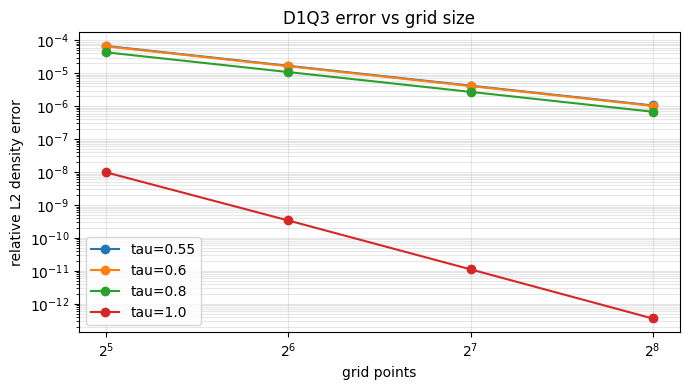

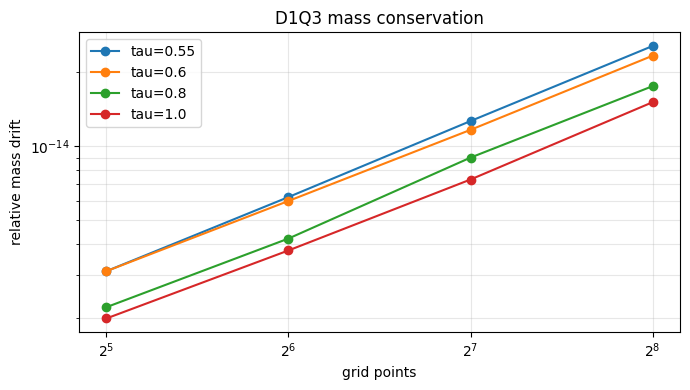

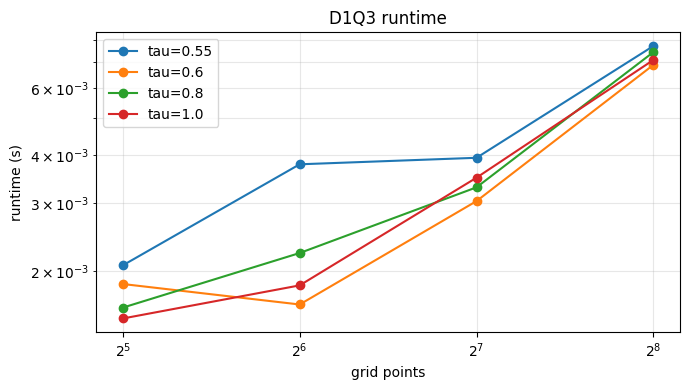

In [4]:
print_best(d1_records, "D1Q3")
plot_by_tau(d1_records, "relative_error", "relative L2 density error", "D1Q3 error vs grid size")
plot_by_tau(d1_records, "mass_drift_relative", "relative mass drift", "D1Q3 mass conservation")
plot_by_tau(d1_records, "runtime_seconds", "runtime (s)", "D1Q3 runtime")

D2Q9 introduces a real 2D velocity field and BGK collision while keeping periodic boundaries. It is the first useful check that our later quantum route is not only solving a toy scalar transport problem.

D2Q9 best error: 1.663e-02 at grid=16x16, tau=1.0


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'D2Q9 runtime'}, xlabel='grid points', ylabel='runtime (s)'>)

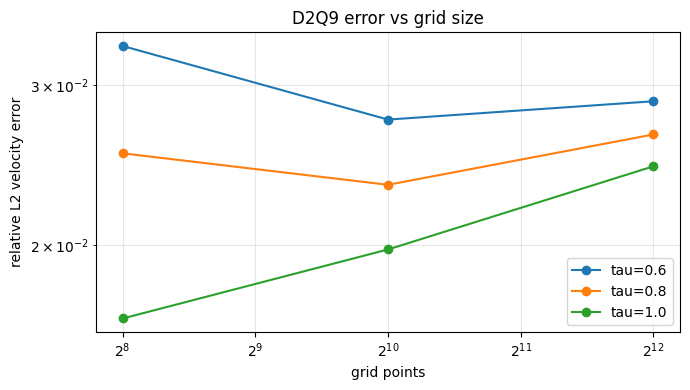

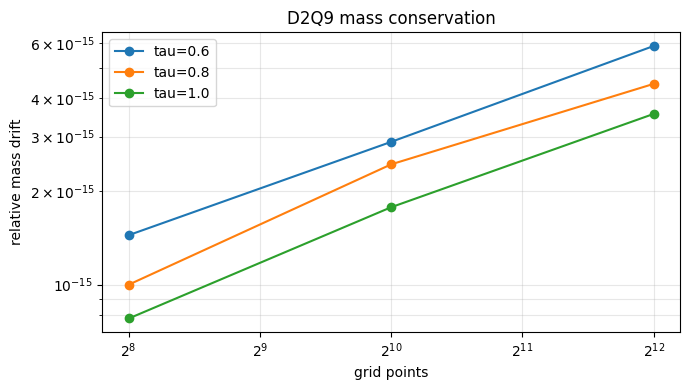

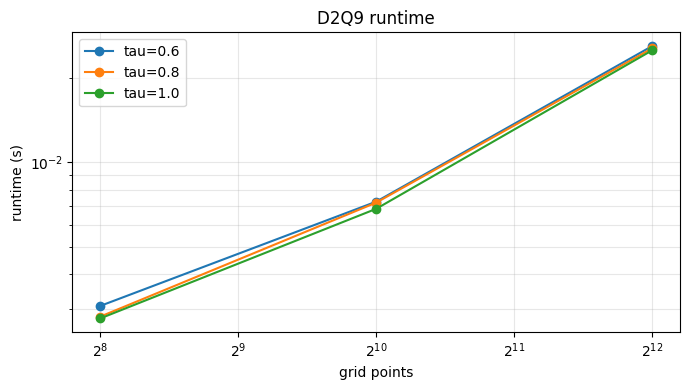

In [5]:
print_best(d2_records, "D2Q9")
plot_by_tau(d2_records, "relative_error", "relative L2 velocity error", "D2Q9 error vs grid size")
plot_by_tau(d2_records, "mass_drift_relative", "relative mass drift", "D2Q9 mass conservation")
plot_by_tau(d2_records, "runtime_seconds", "runtime (s)", "D2Q9 runtime")

## Analysis of Current Sweep Outputs

The classical sweep confirms that the project has a reliable minimal benchmark. D1Q3 is excellent: mass drift is at roundoff level and the density error follows a clean second-order pattern for the main relaxation times. That makes D1Q3 the right next target for an operator-model quantum emulation.

D2Q9 is also stable in this sweep, but the sweep is only a coarse characterization. Its velocity errors sit in the few-percent range, mass conservation is still at roundoff level, and runtime remains small for the tested grids. However, this sweep varies grid size and timestep count together, so it should not be used as the final convergence argument.


In [ ]:
from collections import defaultdict

all_records = [*d1_records, *d2_records]
by_model = defaultdict(list)
for record in all_records:
    by_model[record.model].append(record)

for model, model_records in by_model.items():
    errors = [record.relative_error for record in model_records]
    mass = [record.mass_drift_relative for record in model_records]
    runtimes = [record.runtime_seconds for record in model_records]
    print(
        f"{model}: cases={len(model_records)}, "
        f"error=[{min(errors):.3e}, {max(errors):.3e}], "
        f"max mass drift={max(mass):.3e}, "
        f"runtime=[{min(runtimes):.3e}, {max(runtimes):.3e}] s"
    )


Interpretation: D1Q3 has done its job as the clean reference problem. D2Q9 has passed stability and conservation checks, but the right question is no longer whether it runs; the right question is why its observed velocity order is not cleanly second order under refinement. That is why the validation and order-study notebooks are the main evidence for the next solver decision.
